In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout,InputLayer, BatchNormalization, GlobalAveragePooling2D, GRU, Reshape
from tensorflow.keras.layers import Input, Dense, LSTM, Conv3D, Flatten
from keras import models, layers
from tensorflow.keras.layers import LSTM, Dense , Dropout
from tensorflow.keras.losses import sparse_categorical_crossentropy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from keras.optimizers import Adam
import pickle
import numpy as np
tf.keras.mixed_precision.set_global_policy('mixed_float16')
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report

# Evaluation

In [2]:
from scipy.interpolate import make_interp_spline
def plot_training_history(history):
    # Số lượng điểm dữ liệu (epochs)
    epochs = len(history.history['accuracy'])
    
    # Check if there are enough epochs to use cubic spline interpolation
    if epochs > 3:
        xnew = np.linspace(0, epochs - 1, 300)  # Tạo thêm điểm dữ liệu để làm mịn đường
        
        # Tính toán spline cho accuracy
        spl_acc = make_interp_spline(range(epochs), history.history['accuracy'], k=3)
        smooth_acc = spl_acc(xnew)
        spl_val_acc = make_interp_spline(range(epochs), history.history['val_accuracy'], k=3)
        smooth_val_acc = spl_val_acc(xnew)

        # Tính toán spline cho loss
        spl_loss = make_interp_spline(range(epochs), history.history['loss'], k=3)
        smooth_loss = spl_loss(xnew)
        spl_val_loss = make_interp_spline(range(epochs), history.history['val_loss'], k=3)
        smooth_val_loss = spl_val_loss(xnew)
    else:
        # Fallback to linear interpolation if not enough data for cubic spline
        xnew = np.linspace(0, epochs - 1, epochs)
        smooth_acc = history.history['accuracy']
        smooth_val_acc = history.history['val_accuracy']
        smooth_loss = history.history['loss']
        smooth_val_loss = history.history['val_loss']

    # Vẽ biểu đồ accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(xnew, smooth_acc, label='Train')
    plt.plot(xnew, smooth_val_acc, label='Test')
    plt.scatter(range(epochs), history.history['accuracy'], color='blue', s=20)  # Thêm chấm cho mỗi epoch
    plt.scatter(range(epochs), history.history['val_accuracy'], color='orange', s=20)
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Vẽ biểu đồ loss
    plt.subplot(1, 2, 2)
    plt.plot(xnew, smooth_loss, label='Train')
    plt.plot(xnew, smooth_val_loss, label='Test')
    plt.scatter(range(epochs), history.history['loss'], color='blue', s=20)  # Thêm chấm cho mỗi epoch
    plt.scatter(range(epochs), history.history['val_loss'], color='orange', s=20)
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    plt.tight_layout()
    plt.show()

    
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes=2, normalize=False, cmap=plt.cm.Blues):
    y_pred = y_pred.reshape(-1).round()
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'

    # Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap, xticklabels=classes, yticklabels=classes, cbar=False)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.title(f'CM, Acc:{accuracy_score(y_true, y_pred)*100:.2f}%')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()
    

In [3]:
class myCallback(tf.keras.callbacks.Callback):
    def __init__(self, patience=5, delta=0.001, max_acc = 0.99):
        super(myCallback, self).__init__()
        self.patience = patience
        self.delta = delta
        self.wait = 0
        self.best_val_acc = -float('inf')
        self.max_acc = max_acc

    def on_epoch_end(self, epoch, logs={}):
        current_val_acc = logs.get('val_accuracy')
        if current_val_acc is None:
            return

        if current_val_acc > self.best_val_acc + self.delta:
            self.best_val_acc = current_val_acc
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.model.stop_training = True
                print("\nTraining stopped as val_accuracy did not improve for {} epochs.".format(self.patience))
            
        if logs.get('val_accuracy') >=  self.max_acc and logs.get('accuracy') >=  self.max_acc:
            self.model.stop_training = True

# Feature Extraction

In [4]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf

def read_data_from_folder(folder_path, sequence_length=130):
    # Chỉ lấy các thư mục 'p1', 'p2', 'p3'
    target_folders =[d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))]
    sequences = []
    labels = []
    person = []
    csv = []
#     min_df = 1000
    for label_num_temp, person_folder in enumerate(target_folders):
        person_folder_path = os.path.join(folder_path, person_folder)
        
        if not os.path.isdir(person_folder_path):
            print(f"Folder {person_folder_path} không tồn tại.")
            continue
        
        print(f"Running for person {person_folder}")
        # print( person)
        
        for csv_file in os.listdir(person_folder_path):
            if not csv_file.endswith('.csv'):
                continue
            
            csv_file_path = os.path.join(person_folder_path, csv_file)
            csv.append(csv_file[:-4])
            df = pd.read_csv(csv_file_path)
            df = df.iloc[:, 1:]  # Chọn các cột từ cột thứ 3 đến cột cuối cùng
            num_frames = min(sequence_length, len(df))  # Đảm bảo không lấy quá nhiều hơn sequence_length frames
            # min_df = min(len(df), min_df)
            # print(min_df, len(df))
            
            sequence = df.iloc[:num_frames].values

            sequences.append(sequence)
            labels.append(label_num_temp)
            person.append(int(person_folder[1:]))

    return dict(zip(csv, sequences)), dict(zip(csv, person)), target_folders


train_folder_path = '/kaggle/input/featuredata-gait-recognition-ver2'
SEQUENCE_LENGTH = 1000  # Độ dài chuỗi mong muốn

# Đọc dữ liệu từ các thư mục p1, p2, p3 trong thư mục train
sequences, labels, class_labels = read_data_from_folder(train_folder_path, sequence_length=SEQUENCE_LENGTH)

Running for person P62
Running for person P50
Running for person P51
Running for person P49
Running for person P54
Running for person P56
Running for person P44
Running for person P60
Running for person P61
Running for person P41
Running for person P46
Running for person P53
Running for person P57
Running for person P52
Running for person P55
Running for person P43
Running for person P63
Running for person P65
Running for person P47
Running for person P59
Running for person P58
Running for person P45
Running for person P48
Running for person P64


In [5]:
parent_dir = '/kaggle/input/featuredata-gait-recognition/'
subdirs = [d for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]
for dir in subdirs:
    seq, label, class_labels = read_data_from_folder(parent_dir + dir, sequence_length=SEQUENCE_LENGTH)
    print(parent_dir + dir)
    sequences.update(seq)
    labels.update(label)

Running for person P3
Running for person P1
Running for person P2
/kaggle/input/featuredata-gait-recognition/output_folders1
Running for person P3
Running for person P5
Running for person P4
/kaggle/input/featuredata-gait-recognition/output_folders2
Running for person P18
Running for person P34
Running for person P17
Running for person P36
Running for person P35
Running for person P29
Running for person P9
Running for person P30
Running for person P10
Running for person P12
Running for person P23
Running for person P15
Running for person P19
Running for person P39
Running for person P33
Running for person P11
Running for person P32
Running for person P22
Running for person P31
Running for person P16
Running for person P8
Running for person P37
Running for person P13
Running for person P20
Running for person P6
Running for person P21
Running for person P14
Running for person P7
Running for person P40
Running for person P27
Running for person P38
Running for person P28
Running for person

In [6]:
parent_dir = '/kaggle/input/feature-distance-matrix-gait-recognition/'
subdirs = [d for d in os.listdir(parent_dir) if os.path.isdir(os.path.join(parent_dir, d))]
matrix_seq = {}
label_ = {}

for dir in subdirs:
    seq, label, class_labels = read_data_from_folder(parent_dir + dir, sequence_length=SEQUENCE_LENGTH)
    print(parent_dir + dir)
    matrix_seq.update(seq)
    label_.update(label)

Running for person P12
Running for person P15
Running for person P11
Running for person P13
Running for person P14
/kaggle/input/feature-distance-matrix-gait-recognition/output_11_15
Running for person P56
Running for person P60
Running for person P57
Running for person P59
Running for person P58
/kaggle/input/feature-distance-matrix-gait-recognition/output_56_60
Running for person P62
Running for person P61
Running for person P63
Running for person P65
Running for person P64
/kaggle/input/feature-distance-matrix-gait-recognition/output_61_65
Running for person P44
Running for person P41
Running for person P43
Running for person P45
/kaggle/input/feature-distance-matrix-gait-recognition/output_41_45
Running for person P9
Running for person P10
Running for person P8
Running for person P6
Running for person P7
/kaggle/input/feature-distance-matrix-gait-recognition/output_6_10
Running for person P34
Running for person P35
Running for person P33
Running for person P32
Running for person P3

In [7]:
# import cv2
# import os
# import numpy as np
# from tqdm import tqdm  # Thêm thư viện tqdm để hiển thị thanh tiến trình

# def get_all_images(folder_path, w=66, h=66):
#     # Lấy danh sách tất cả các file ảnh .png và kiểm tra số lượng
#     filenames = sorted([f for f in os.listdir(folder_path) if f.endswith(".png")])
    
#     # Nếu không đủ 66 frames, bỏ qua thư mục này
#     if len(filenames) < 66:
#         # print(f"Folder {folder_path} skipped because it does not have enough frames.")
#         return None

#     # Đọc tất cả các ảnh và chuẩn hóa về kích thước và khoảng 0...1
#     images = []
#     for filename in filenames:
#         img_path = os.path.join(folder_path, filename)
#         img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
#         if img is not None:
#             img = cv2.resize(img.astype(np.float32) / 255.0, (w, h))
#             images.append(img)
#         else:
#             print(f"Warning: Cannot load {img_path}")

#     return images if images else None

# def process_all_folders(base_folder):
#     all_images = []
#     person = []
#     total_images = 0
    
#     # Tính tổng số ảnh để hiển thị thanh tiến trình chính xác
#     for person_folder in sorted(os.listdir(base_folder)):
#         person_path = os.path.join(base_folder, person_folder)
#         if os.path.isdir(person_path):
#             for img_folder in sorted(os.listdir(person_path)):
#                 img_folder_path = os.path.join(person_path, img_folder)
#                 if os.path.isdir(img_folder_path):
#                     # Lấy danh sách ảnh để tính tổng số ảnh
#                     filenames = sorted([f for f in os.listdir(img_folder_path) if f.endswith(".png")])
#                     if len(filenames) >= 66:
#                         total_images += len(filenames)

#     # Khởi tạo thanh tiến trình cho toàn bộ quá trình
#     with tqdm(total=total_images, desc="Processing Images", unit="image") as pbar:
#         for person_folder in sorted(os.listdir(base_folder)):
#             person_path = os.path.join(base_folder, person_folder)
#             if os.path.isdir(person_path):
#                 for img_folder in sorted(os.listdir(person_path)):
#                     img_folder_path = os.path.join(person_path, img_folder)
#                     if os.path.isdir(img_folder_path):
#                         imgs = get_all_images(img_folder_path)
#                         if imgs is not None:
#                             all_images.append(imgs)
#                             person.append(img_folder[:-4])
#                             pbar.update(len(imgs))  # Cập nhật thanh tiến trình theo số lượng ảnh đã đọc

#     return dict(zip(person, all_images))  # Sử dụng dtype=object để lưu trữ các mảng với kích thước khác nhau

# # Đường dẫn đến thư mục chính
# base_path = "/kaggle/input/featuredata-gait-recognition/Gait Dataset Feature"
# img_array = process_all_folders(base_path)
# print("Processed", len(img_array), "sets of images.")

In [8]:
import cv2
import os
import numpy as np
from tqdm import tqdm  # Thêm thư viện tqdm để hiển thị thanh tiến trình

def get_middle_images(folder_path, w=66, h=66, num_images=20):
    # Lấy danh sách tất cả các file ảnh .png và kiểm tra số lượng
    filenames = sorted([f for f in os.listdir(folder_path) if f.endswith(".png")])
    
    # Nếu không đủ 66 frames, bỏ qua thư mục này
    if len(filenames) < 66:
        return None

    # Lấy 20 ảnh từ vị trí giữa của danh sách
    start_index = (len(filenames) - num_images) // 2
    middle_filenames = filenames[start_index - (num_images//2):start_index + (num_images//2)]

    # Đọc các ảnh và chuẩn hóa về kích thước và khoảng 0...1
    images = []
    for filename in middle_filenames:
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img.astype(np.float32) / 255.0, (w, h))
            images.append(img)
        else:
            print(f"Warning: Cannot load {img_path}")

    return images if images else None

def process_all_folders(base_folder):
    all_images = []
    person = []
    total_images = 0
    
    # Tính tổng số ảnh để hiển thị thanh tiến trình chính xác
    for person_folder in sorted(os.listdir(base_folder)):
        person_path = os.path.join(base_folder, person_folder)
        if os.path.isdir(person_path):
            for img_folder in sorted(os.listdir(person_path)):
                img_folder_path = os.path.join(person_path, img_folder)
                if os.path.isdir(img_folder_path):
                    filenames = sorted([f for f in os.listdir(img_folder_path) if f.endswith(".png")])
                    if len(filenames) >= 66:
                        total_images += len(filenames)

    # Khởi tạo thanh tiến trình cho toàn bộ quá trình
    with tqdm(total=total_images, desc="Processing Images", unit="image") as pbar:
        for person_folder in sorted(os.listdir(base_folder)):
            person_path = os.path.join(base_folder, person_folder)
            if os.path.isdir(person_path):
                for img_folder in sorted(os.listdir(person_path)):
                    img_folder_path = os.path.join(person_path, img_folder)
                    if os.path.isdir(img_folder_path):
                        imgs = get_middle_images(img_folder_path)
                        if imgs is not None:
                            all_images.append(imgs)
                            person.append(img_folder[:-4])
                            pbar.update(len(imgs))  # Cập nhật thanh tiến trình theo số lượng ảnh đã đọc

    return dict(zip(person, all_images))  # Sử dụng dtype=object để lưu trữ các mảng với kích thước khác nhau

# Đường dẫn đến thư mục chính
base_path = "/kaggle/input/featuredata-gait-recognition/Gait Dataset Feature"
img_array = process_all_folders(base_path)
print("Processed", len(img_array), "sets of images.")


Processing Images:  11%|█         | 30720/281189 [09:43<1:19:19, 52.63image/s]

Processed 1536 sets of images.


In [9]:
base_path = "/kaggle/input/featuredata-gait-recognition/output_folders1"
img_array.update(process_all_folders(base_path))

base_path = "/kaggle/input/featuredata-gait-recognition/output_folders2"
img_array.update(process_all_folders(base_path))

Processing Images:  11%|█         | 2880/25813 [00:53<07:03, 54.12image/s]


In [10]:
base_path = "/kaggle/input/featuredata-gait-recognition-ver2"
img_array.update(process_all_folders(base_path))

Processing Images:  10%|▉         | 22840/235591 [07:16<1:07:48, 52.29image/s]


In [11]:
# # Lưu dictionary vào file
# with open('img_dict.pkl', 'wb') as f:
#     pickle.dump(img_array, f)

In [12]:
# with open('/kaggle/input/gait-img/img_dict.pkl', 'rb') as f:
#     loaded_dict = pickle.load(f)

In [13]:
loaded_dict = img_array

In [14]:
import numpy as np
from tqdm import tqdm  # Thêm thư viện tqdm để hiển thị thanh tiến trình

# Tạo một generator để lưu trữ X và labels
def generate_X_and_labels(loaded_dict, sequences, matrix_seq):
    labels = []  # Danh sách để lưu trữ labels
    for key in loaded_dict:
        # if key not in sequences or key not in matrix_seq:
        #     continue
        if sequences[key].shape[0] < 66 or matrix_seq[key].shape[0] < 66:
            continue
        for img in loaded_dict[key]:
            # Sử dụng kiểu dữ liệu float16 để giảm bộ nhớ
            yield np.stack((sequences[key][:66, :].astype(np.float16), 
                             matrix_seq[key][:66, :66].astype(np.float16), 
                             img.astype(np.float16)), axis=-1), int(key[1:key.find('_')])

# Sử dụng generator để tạo mảng X và labels
X_list = []
labels = []
total_images = sum(len(loaded_dict[key]) for key in loaded_dict if key in sequences and key in matrix_seq and sequences[key].shape[0] >= 66 and matrix_seq[key].shape[0] >= 66)

with tqdm(total=total_images, desc="Processing Images") as pbar:  # Khởi tạo thanh tiến trình
    for x, label in generate_X_and_labels(loaded_dict, sequences, matrix_seq):
        X_list.append(x)
        labels.append(label)
        pbar.update(1)  # Cập nhật thanh tiến trình mỗi khi một phần tử được thêm vào

# Chuyển đổi danh sách thành mảng NumPy
X = np.array(X_list)
y = np.array(labels) - 1

print(X.shape)
print(y.shape)
np.unique(y)


Processing Images: 100%|██████████| 58300/58300 [00:06<00:00, 9233.17it/s]


(58300, 66, 66, 3)
(58300,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64])

In [15]:
unique_classes = np.unique(y)  # Lấy các lớp duy nhất
class_map = {original: new for new, original in enumerate(unique_classes)}  # Ánh xạ mỗi lớp gốc thành lớp mới liên tiếp

# Áp dụng ánh xạ để chuẩn hóa y
y= np.array([class_map[val] for val in y])
np.unique(y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [16]:
np.savez('/kaggle/working/data.npz', X=X, y=y)

In [17]:
# data = np.load('/kaggle/input/gait-img/data.npz')

In [18]:
# X = data['X'].astype(np.float16)  # Chuyển đổi X thành float16
# y = data['y'].astype(np.int8)

In [19]:
np.unique(y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63])

In [20]:
xtrain, xvalid, ytrain, yvalid = train_test_split(X, y, test_size=0.6, random_state=42)
xvalid, xtest, yvalid, ytest = train_test_split(xvalid, yvalid, test_size=0.5, random_state=42)

print("Training set shape:", xtrain.shape)
print("Validation set shape:", xvalid.shape)
print("Test set shape:", xtest.shape)
print("Number of training labels:", ytrain.shape)
print("Number of validation labels:", yvalid.shape)
print("Number of test labels:", ytest.shape)

print("The total number of labels is:", len(np.unique(y)))

Training set shape: (23320, 66, 66, 3)
Validation set shape: (17490, 66, 66, 3)
Test set shape: (17490, 66, 66, 3)
Number of training labels: (23320,)
Number of validation labels: (17490,)
Number of test labels: (17490,)
The total number of labels is: 64


In [21]:
shape_input = (X.shape[-3], X.shape[-2], X.shape[-1])
num_classes = len(np.unique(y))

# MobileNet

/tmp/ipykernel_22/957587682.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  MobileNet_base_model = MobileNet(include_top=False, weights='imagenet', input_shape=shape_input)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200


I0000 00:00:1731345620.295635      73 service.cc:145] XLA service 0x7d6bd008ca00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731345620.296762      73 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731345620.296770      73 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 35/729 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.0166 - loss: 4.6414

I0000 00:00:1731345626.659384      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


729/729 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.1427 - loss: 3.6973 - val_accuracy: 0.6704 - val_loss: 1.8223
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6246 - loss: 1.7361 - val_accuracy: 0.8401 - val_loss: 1.0053
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7886 - loss: 1.0672 - val_accuracy: 0.9248 - val_loss: 0.6357
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8579 - loss: 0.7547 - val_accuracy: 0.9472 - val_loss: 0.4523
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8967 - loss: 0.5749 - val_accuracy: 0.9626 - val_loss: 0.3392
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9153 - loss: 0.4718 - val_accuracy: 0.9735 - val_loss: 0.2595
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9304 - loss: 0.3840 - val_accuracy: 0.9800 - val_loss: 0.2056
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9455 - loss: 0.3131 - val_accuracy: 0.98

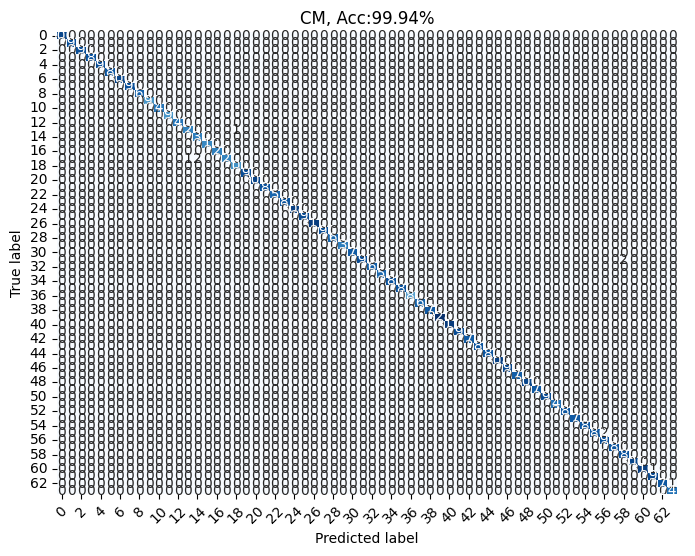

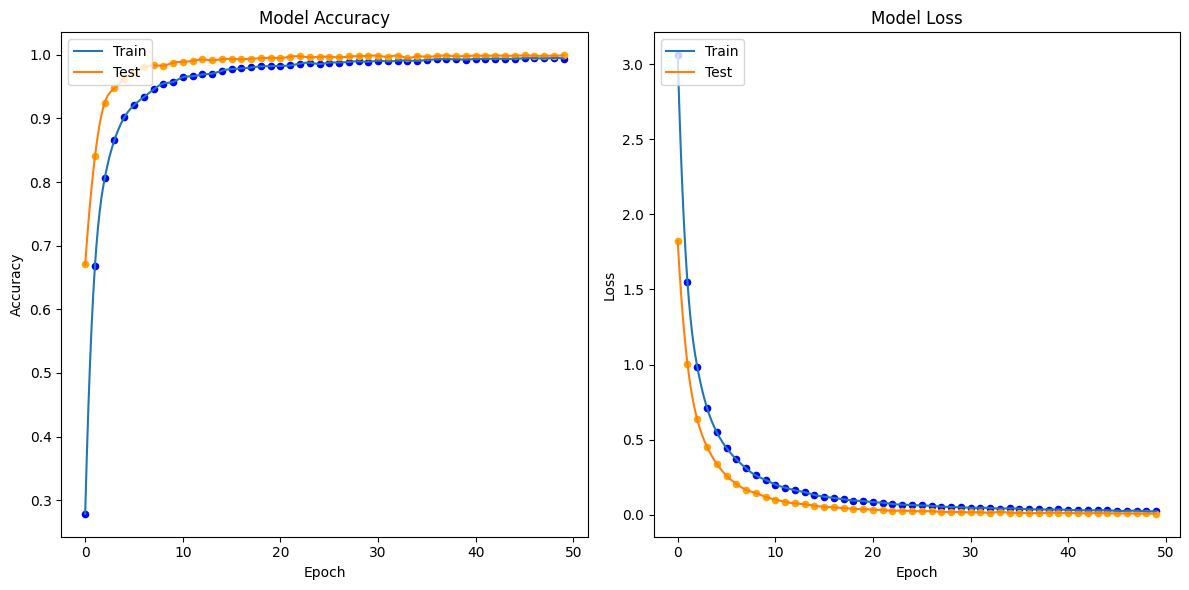

In [22]:
import numpy as np
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

MobileNet_base_model = MobileNet(include_top=False, weights='imagenet', input_shape=shape_input)

# Thêm các lớp tùy chỉnh
x = MobileNet_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)  # Thêm lớp Dropout để giảm hiện tượng overfitting
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Định nghĩa mô hình hoàn chỉnh
MobileNet_model = Model(inputs=MobileNet_base_model.input, outputs=predictions)

# Đóng băng các lớp của mô hình cơ sở
for layer in MobileNet_base_model.layers:
    layer.trainable = False  # Đóng băng các lớp để chỉ đào tạo các lớp tùy chỉnh

# Biên dịch mô hình
MobileNet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Định nghĩa callback
callback1 = myCallback(patience=20, max_acc=1)

# Huấn luyện mô hình
history1 = MobileNet_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=(xvalid, yvalid),
          callbacks=[callback1])

# Dự đoán và đánh giá mô hình
ypred1 = MobileNet_model.predict(xtest)
ypred1 = np.argmax(ypred1, axis=1)

# Vẽ ma trận nhầm lẫn và lịch sử huấn luyện
plot_confusion_matrix(ytest, ypred1)
plot_training_history(history1)

In [23]:
print(classification_report(ytest, ypred1, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       1.00      1.00      1.00       286
     Class 4       1.00      1.00      1.00       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       1.00      1.00      1.00       225
    Class 14       0.99      1.00      1.00       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       1.00    

# EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 190s 126ms/step - accuracy: 0.4366 - loss: 2.1721 - val_accuracy: 0.2775 - val_loss: 3.3287
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9160 - loss: 0.2658 - val_accuracy: 0.8728 - val_loss: 0.4457
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9435 - loss: 0.1835 - val_accuracy: 0.9622 - val_loss: 0.1110
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9648 - loss: 0.1174 - val_accuracy: 0.9480 - val_loss: 0.1907
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9672 - loss: 0.1124 - val_accuracy: 0.9310 - val_loss: 0.2383
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.9618 - loss: 0.1487 - val_accuracy: 0.7688 - val_loss: 1.0252
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9684 - loss: 0.1219 - val_accuracy: 0.9287 - val_loss: 0.2344
Epoch 8/200
729/729 ━━━━━━━━━━

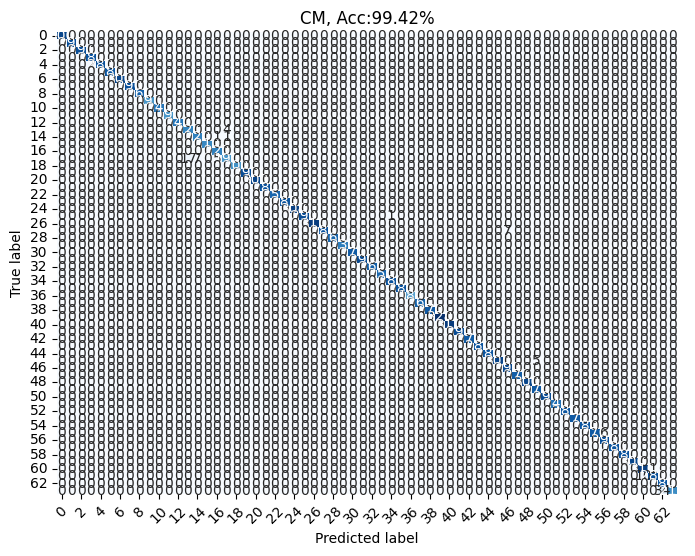

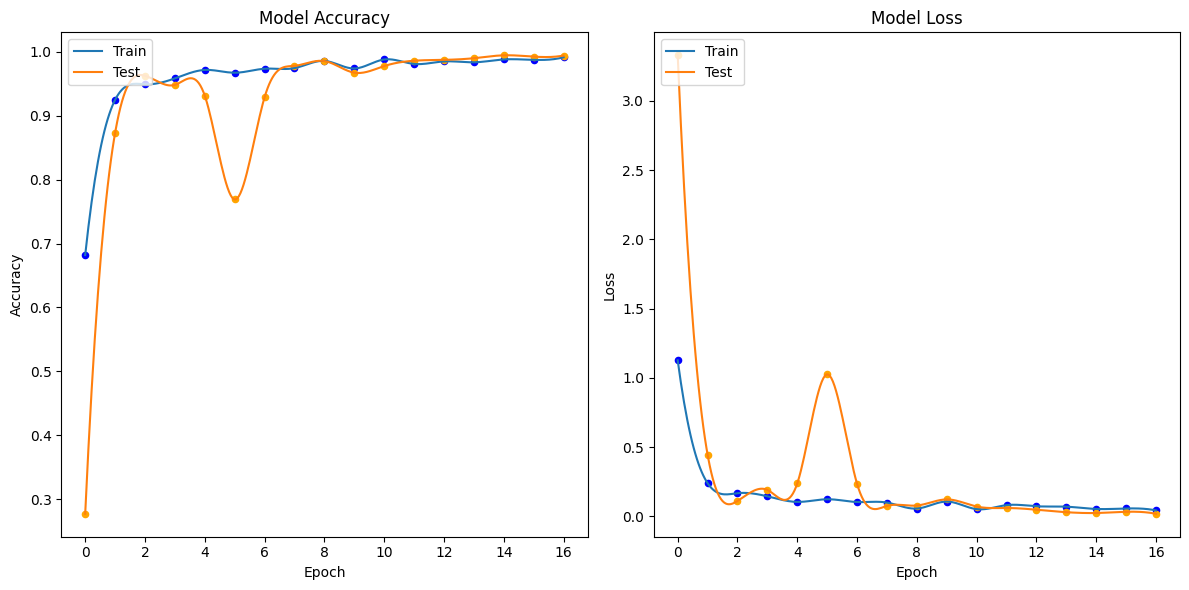

In [24]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
# Tải mô hình EfficientNetB0 với trọng số được đào tạo trên ImageNet
EfficientNetB0_base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=shape_input)

# Thêm các lớp tùy chỉnh
x = EfficientNetB0_base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)  # Thêm lớp Dropout để giảm hiện tượng overfitting
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Định nghĩa mô hình hoàn chỉnh
EfficientNetB0_model = Model(inputs=EfficientNetB0_base_model.input, outputs=predictions)

# Đóng băng các lớp của mô hình cơ sở
for layer in EfficientNetB0_base_model.layers:
    layer.trainable = True

# Biên dịch mô hình
EfficientNetB0_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback11 = myCallback(patience=200)
history11 = EfficientNetB0_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback11)
ypred11 = EfficientNetB0_model.predict(xtest)
ypred11 = np.argmax(ypred11, axis=1)
plot_confusion_matrix(ytest, ypred11)
plot_training_history(history11)

In [25]:
print(classification_report(ytest, ypred11, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       0.99      1.00      1.00       286
     Class 4       1.00      0.99      1.00       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       0.93      0.98      0.95       225
    Class 14       0.97      0.99      0.98       230
    Class 15       1.00      1.00      1.00       217
    Class 16       0.97      1.00      0.99       227
    Class 17       0.97    

# ShuffleNet

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

def channel_shuffle(x, groups):
    height, width, num_channels = x.shape[1], x.shape[2], x.shape[3]
    channels_per_group = num_channels // groups

    # Reshape để shuffle
    x = layers.Reshape((height, width, groups, channels_per_group))(x)

    # Transpose dimensions để shuffle các kênh
    x = layers.Permute((1, 2, 4, 3))(x)

    # Flatten lại sau shuffle
    x = layers.Reshape((height, width, num_channels))(x)

    return x


def shuffle_block(x, out_channels, strides, groups):
    if strides == 2:
        # Giảm kích thước bằng cách sử dụng Average Pooling
        left_branch = layers.AveragePooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)
        left_branch = layers.Conv2D(out_channels//2, 1, strides=1, padding='same')(left_branch)
    else:
        left_branch = layers.Conv2D(out_channels//2, 1, strides=1, padding='same')(x)

    right_branch = layers.DepthwiseConv2D(kernel_size=3, strides=strides, padding='same')(x)
    right_branch = layers.BatchNormalization()(right_branch)
    right_branch = layers.Conv2D(out_channels//2, 1, strides=1, padding='same')(right_branch)

    x = layers.Concatenate()([left_branch, right_branch])
    x = channel_shuffle(x, groups)

    return x
def ShuffleNet(input_shape=shape_input, num_classes=num_classes, groups=3):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(24, kernel_size=3, strides=2, padding='same')(inputs)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Lặp lại các shuffle block
    num_shuffle_units = [3, 7, 3]  # số lượng block trong mỗi giai đoạn
    out_channels = [144, 288, 576]  # số lượng kênh đầu ra cho mỗi block

    for stage, repeat in enumerate(num_shuffle_units):
        for i in range(repeat):
            x = shuffle_block(x, out_channels=out_channels[stage], strides=2 if i == 0 else 1, groups=groups)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

# Tạo mô hình
ShuffleNet_model = ShuffleNet()
ShuffleNet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 66, 66, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 33, 33,    │        672 │ input_layer_2[0]… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d    │ (None, 9, 9, 24)  │        240 │ max_pooling2d[0]… │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 9, 9, 24)  │          0 │ max_pooling2d[0]… │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 9, 9, 24)  │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 9, 9, 72)  │      1,800 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 9, 9, 72)  │      1,800 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 9, 9, 144) │          0 │ conv2d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 9, 9, 3,   │          0 │ concatenate[0][0] │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 9, 9, 48,  │          0 │ reshape[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 9, 9, 144) │          0 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 9, 9, 144) │      1,440 │ reshape_1[0][0]   │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 9, 9, 144) │        576 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 9, 9, 72)  │     10,440 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 9, 9, 72)  │     10,440 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 9, 9, 144) │          0 │ conv2d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 9, 9, 3,   │          0 │ concatenate_1[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,506,016 (5.74 MB)

 Trainable params: 1,498,768 (5.72 MB)

 Non-trainable params: 7,248 (28.31 KB)

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 67s 45ms/step - accuracy: 0.5469 - loss: 1.8631 - val_accuracy: 0.8341 - val_loss: 0.5436
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8885 - loss: 0.3602 - val_accuracy: 0.9612 - val_loss: 0.1118
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9590 - loss: 0.1126 - val_accuracy: 0.9612 - val_loss: 0.1344
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8700 - loss: 0.5295 - val_accuracy: 0.9592 - val_loss: 0.1127
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9707 - loss: 0.0840 - val_accuracy: 0.3768 - val_loss: 7.2639
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8939 - loss: 0.4056 - val_accuracy: 0.9730 - val_loss: 0.0644
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9744 - loss: 0.0769 - val_accuracy: 0.6678 - val_loss: 2.2619
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9264 - loss: 0.2482 -

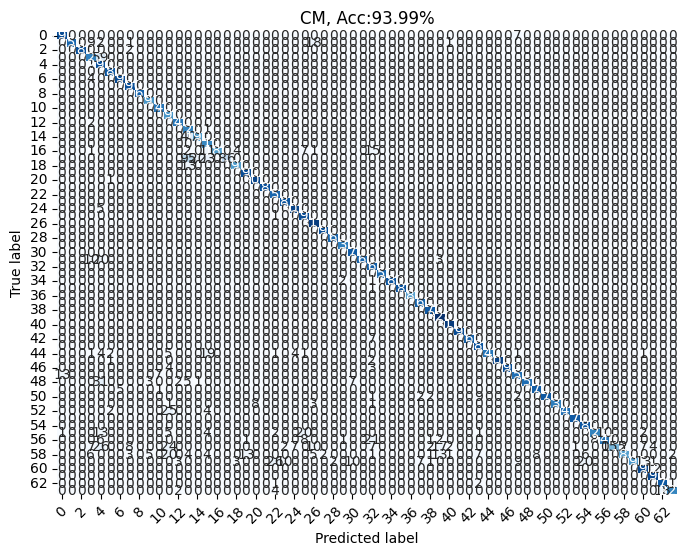

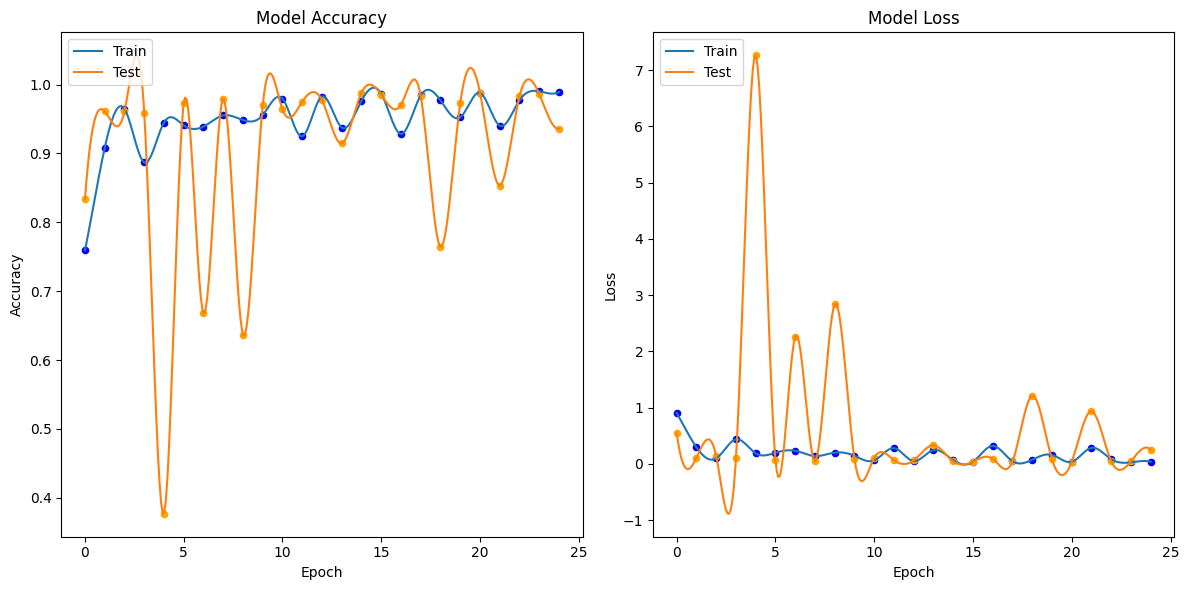

In [27]:
ShuffleNet_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback2 = myCallback(patience=10)
history2 = ShuffleNet_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback2)
ypred2 = ShuffleNet_model.predict(xtest)
ypred2 = np.argmax(ypred2, axis=1)
plot_confusion_matrix(ytest, ypred2)
plot_training_history(history2)

In [28]:
print(classification_report(ytest, ypred2, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       0.95      0.98      0.97       300
     Class 1       1.00      0.89      0.94       290
     Class 2       1.00      0.99      1.00       291
     Class 3       0.85      0.79      0.82       286
     Class 4       0.64      1.00      0.78       291
     Class 5       0.98      1.00      0.99       280
     Class 6       0.98      0.99      0.99       300
     Class 7       0.95      1.00      0.98       290
     Class 8       1.00      1.00      1.00       266
     Class 9       0.96      1.00      0.98       197
    Class 10       0.97      1.00      0.98       240
    Class 11       0.70      1.00      0.83       199
    Class 12       0.97      0.99      0.98       242
    Class 13       0.58      1.00      0.74       225
    Class 14       0.90      0.83      0.86       230
    Class 15       0.77      1.00      0.87       217
    Class 16       1.00      0.82      0.90       227
    Class 17       1.00    

# ConvNeXt

In [29]:
from tensorflow.keras import layers, models, Input

def ConvNeXt_block(dim, kernel_size=7):
    def layer(x):
        # Layer normalization inside the convolution block
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        
        # Depthwise convolution
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, strides=1, padding="same", use_bias=False)(x)
        
        # Pointwise convolution to mix channels
        x = layers.Conv2D(dim, kernel_size=1, strides=1, use_bias=False)(x)
        x = layers.Activation("gelu")(x)  # Using GELU activation
        
        return x
    return layer

def build_convnext_model(input_shape, num_classes=64, num_blocks=4, dim=96):
    inputs = Input(shape=input_shape)

    # Initial convolution layer
    x = layers.Conv2D(dim, kernel_size=4, strides=4, padding="same")(inputs)

    # Stacking ConvNeXt blocks
    for _ in range(num_blocks):
        x = ConvNeXt_block(dim)(x)

    # Final layers and classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='gelu')(x)  # Large dense layer before classification
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # Create the Keras model
    model = models.Model(inputs=inputs, outputs=outputs)

    return model

convnext_model = build_convnext_model(shape_input, num_classes)
convnext_model.compile(optimizer=Adam(learning_rate=1e-4),
                       loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.0238 - loss: 4.0687 - val_accuracy: 0.0512 - val_loss: 3.6984
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0603 - loss: 3.6012 - val_accuracy: 0.1484 - val_loss: 3.0302
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1618 - loss: 2.9294 - val_accuracy: 0.2969 - val_loss: 2.3443
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2887 - loss: 2.3171 - val_accuracy: 0.4972 - val_loss: 1.7600
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4094 - loss: 1.8301 - val_accuracy: 0.5970 - val_loss: 1.3209
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5363 - loss: 1.4134 - val_accuracy: 0.7397 - val_loss: 0.9249
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6497 - loss: 1.0541 - val_accuracy: 0.7908 - val_loss: 0.7305
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7241 - loss: 0.8198 - val_ac

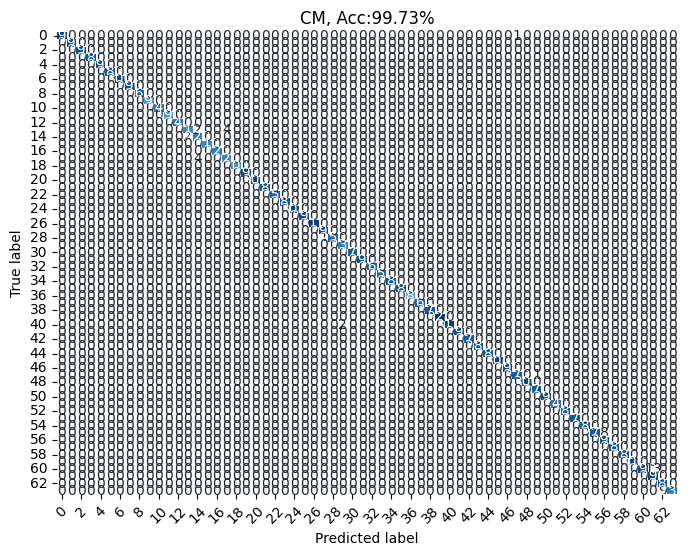

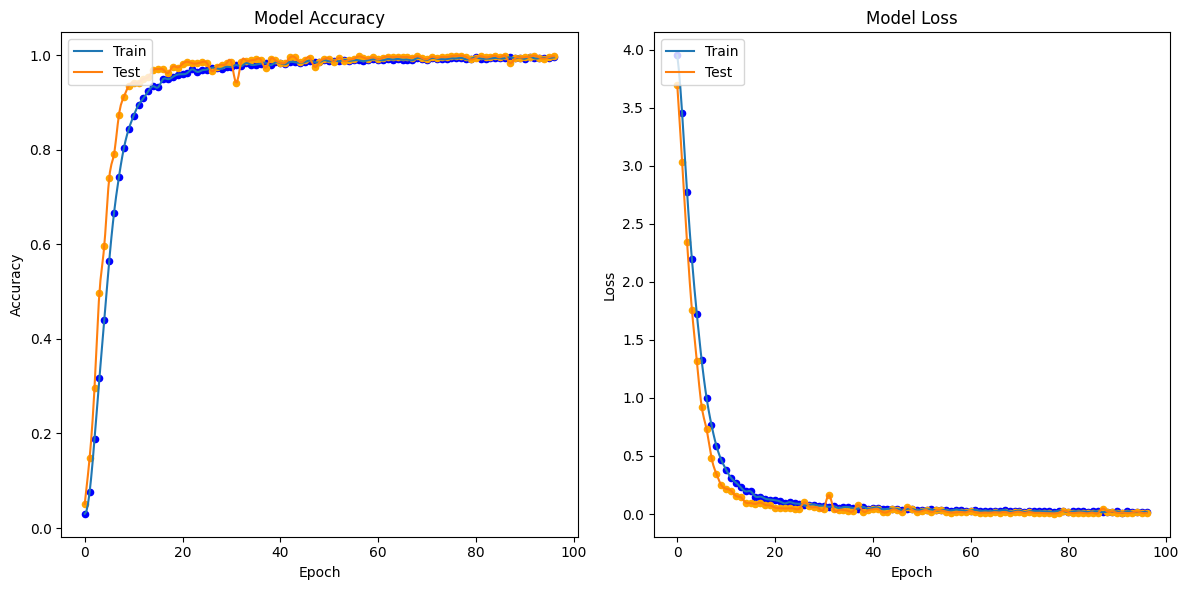

In [30]:
callback4 = myCallback(patience=20,max_acc=1)
history4 = convnext_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback4)
ypred4 = convnext_model.predict(xtest)
ypred4 = np.argmax(ypred4, axis=1)
plot_confusion_matrix(ytest, ypred4)
plot_training_history(history4)

In [31]:
print(classification_report(ytest, ypred4, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       1.00      1.00      1.00       286
     Class 4       1.00      1.00      1.00       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       0.99      0.97      0.98       225
    Class 14       0.97      0.99      0.98       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       0.98    

# ResNeSt

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models

def split_attention_block(filters, cardinality, reduction_factor=16, adjust_residual=False):
    def block(x):
        # Residual path
        residual = x

        # Adjusting the residual path if the number of filters changes
        if adjust_residual:
            residual = layers.Conv2D(filters, kernel_size=1, strides=1, padding='same')(residual)
            residual = layers.BatchNormalization()(residual)

        # Grouped convolutions
        grouped = layers.Conv2D(filters * 2, kernel_size=1, groups=cardinality, padding='same')(x)
        grouped = layers.BatchNormalization()(grouped)
        grouped = layers.Activation('relu')(grouped)

        # Channel-wise attention via global average pooling and dense layers
        gap = layers.GlobalAveragePooling2D()(grouped)
        gap = layers.Dense(filters * 2 // reduction_factor, activation='relu')(gap)
        gap = layers.Dense(filters * 2)(gap)
        attention = layers.Reshape((1, 1, filters * 2))(gap)
        attention = layers.Activation('sigmoid')(attention)
        
        # Attention applied
        reduced = layers.Multiply()([grouped, attention])

        # Merging blocks
        reduced = layers.Conv2D(filters, kernel_size=1)(reduced)
        reduced = layers.BatchNormalization()(reduced)
        
        # Adding residual
        return layers.Add()([residual, reduced])
    return block

def build_resnest(input_shape, num_classes, dim=96):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(dim, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.DepthwiseConv2D(kernel_size=7, strides=1, padding="same", use_bias=False)(x)
    x = layers.Conv2D(dim, kernel_size=1, strides=1, use_bias=False)(x)
    # Using the split-attention block with adjustment
    x = split_attention_block(filters=dim, cardinality=1)(x) 
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.0604 - loss: 3.9069 - val_accuracy: 0.1145 - val_loss: 3.5775
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2074 - loss: 3.2179 - val_accuracy: 0.1307 - val_loss: 3.6026
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4029 - loss: 2.5361 - val_accuracy: 0.2448 - val_loss: 2.9575
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5754 - loss: 1.9413 - val_accuracy: 0.2708 - val_loss: 2.6196
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7278 - loss: 1.4389 - val_accuracy: 0.3994 - val_loss: 2.0793
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8152 - loss: 1.0489 - val_accuracy: 0.5160 - val_loss: 1.5790
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8718 - loss: 0.7790 - val_accuracy: 0.2700 - val_loss: 3.7923
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9049 - loss: 0.5816 - val_ac

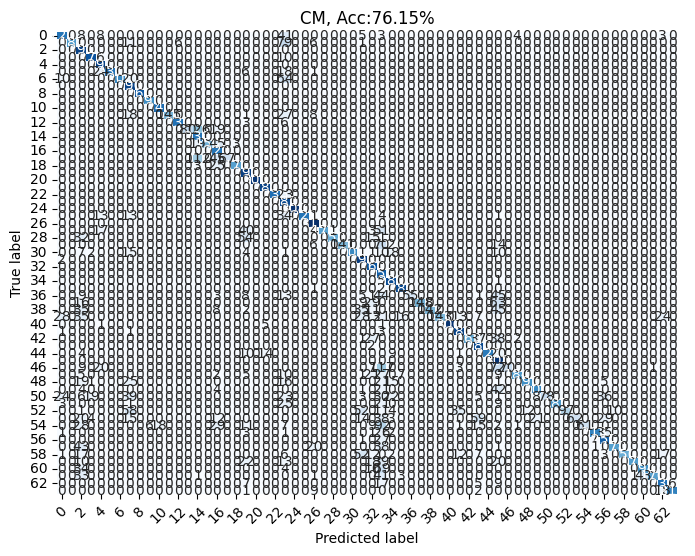

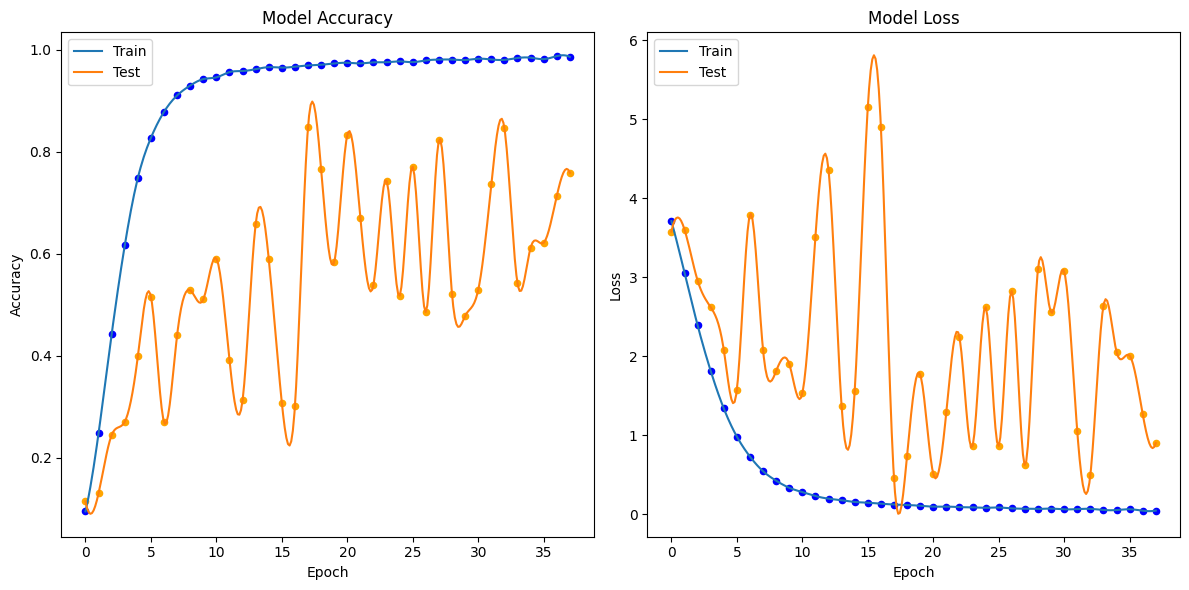

In [33]:
resnest_model = build_resnest(shape_input, num_classes, dim=128)
resnest_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback_0 = myCallback(patience=20, max_acc=1)
history_0 = resnest_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback_0)
ypred_0 = resnest_model.predict(xtest)
ypred_0 = np.argmax(ypred_0, axis=1)
plot_confusion_matrix(ytest, ypred_0)
plot_training_history(history_0)

In [34]:
print(classification_report(ytest, ypred_0, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       0.77      0.76      0.76       300
     Class 1       1.00      0.64      0.78       290
     Class 2       0.44      1.00      0.61       291
     Class 3       0.91      0.94      0.93       286
     Class 4       0.77      1.00      0.87       291
     Class 5       1.00      0.82      0.90       280
     Class 6       1.00      0.69      0.81       300
     Class 7       0.57      1.00      0.73       290
     Class 8       1.00      1.00      1.00       266
     Class 9       0.97      1.00      0.98       197
    Class 10       0.93      1.00      0.96       240
    Class 11       1.00      0.73      0.84       199
    Class 12       0.97      0.96      0.97       242
    Class 13       1.00      0.36      0.52       225
    Class 14       0.47      1.00      0.64       230
    Class 15       1.00      0.69      0.82       217
    Class 16       0.54      1.00      0.70       227
    Class 17       1.00    

# Vision Trasformer

In [35]:
class Patches(layers.Layer):
    def __init__(self, patch_size, num_patches, d_model, **kwargs):
        super(Patches, self).__init__(**kwargs)
        self.patch_size = patch_size
        self.num_patches = num_patches
        self.d_model = d_model
        # self.conv = layers.Conv2D(filters=self.d_model, kernel_size=self.patch_size, 
        #                          strides=self.patch_size, padding='valid')
        self.conv = layers.SeparableConv2D(filters=self.d_model, kernel_size=self.patch_size, 
                                           strides=self.patch_size, padding='valid')
        self.bn = layers.BatchNormalization()  # Batch Normalization after convolution

    def call(self, inputs):
        patches = self.conv(inputs)
        patches = self.bn(patches)  # Apply Batch Normalization
        batch_size = tf.shape(inputs)[0]
        patches = tf.reshape(patches, [batch_size, self.num_patches, self.d_model])
        return patches

def transformer_encoder(inputs, d_model, num_heads, mlp_dim, dropout_rate):
    # Multi-Head Self Attention
    attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads)(inputs, inputs)
    attention_output = layers.Dropout(dropout_rate)(attention_output)
    res = layers.add([inputs, attention_output])
    
    # Feedforward layer with Batch Normalization
    norm1 = layers.LayerNormalization(epsilon=1e-6)(res)
    mlp_output = layers.Conv1D(filters=mlp_dim, kernel_size=1, activation="relu")(norm1)
    mlp_output = layers.BatchNormalization()(mlp_output)  # Apply Batch Normalization
    mlp_output = layers.Conv1D(filters=d_model, kernel_size=1)(mlp_output)
    mlp_output = layers.Dropout(dropout_rate)(mlp_output)
    res = layers.add([res, mlp_output])
    
    return res


def create_vit_model(image_size, patch_size, num_classes, num_layers, d_model, num_heads, mlp_dim, dropout_rate=0.1):
    num_patches = (image_size // patch_size) ** 2
    input_shape = (image_size, image_size, 3)
    
    # Input embedding
    inputs = tf.keras.Input(shape=input_shape)
    patches = Patches(patch_size, num_patches, d_model)(inputs)
    
    # Positional encoding
    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embeddings = layers.Embedding(input_dim=num_patches, output_dim=d_model)(positions)
    patches += position_embeddings
    
    # Transformer Encoder layers
    for _ in range(num_layers):
        patches = transformer_encoder(patches, d_model, num_heads, mlp_dim, dropout_rate)
    
    # Global Average Pooling
    output = layers.GlobalAveragePooling1D()(patches)
    
    # Fully Connected layer for classification
    output = layers.Dense(num_classes, activation="sigmoid")(output)
    
    model = Model(inputs=inputs, outputs=output)
    return model

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 88s 61ms/step - accuracy: 0.0296 - loss: 3.9556 - val_accuracy: 0.0443 - val_loss: 3.6047
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.0472 - loss: 3.5531 - val_accuracy: 0.0680 - val_loss: 3.2121
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.0749 - loss: 3.2365 - val_accuracy: 0.1568 - val_loss: 3.0088
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.1754 - loss: 2.8299 - val_accuracy: 0.3325 - val_loss: 2.2172
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.2714 - loss: 2.4328 - val_accuracy: 0.4767 - val_loss: 1.7337
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3626 - loss: 2.0882 - val_accuracy: 0.5618 - val_loss: 1.4493
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4382 - loss: 1.8161 - val_accuracy: 0.6599 - val_loss: 1.1266
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4950 - loss: 1.6035 -

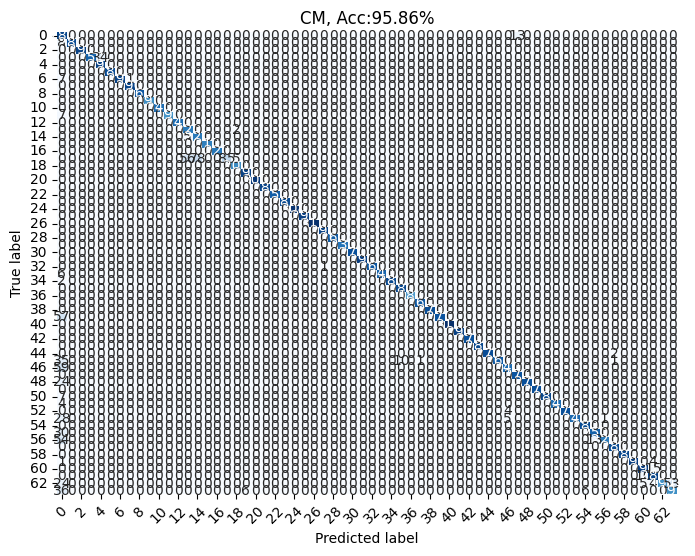

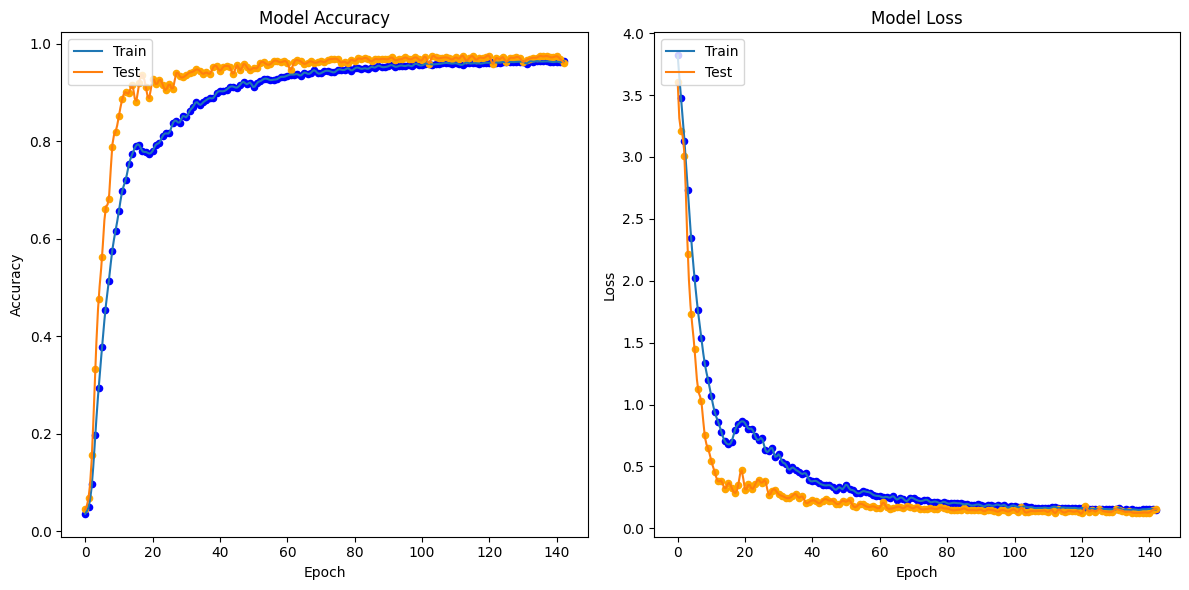

In [36]:
image_size = 66
patch_size = 11
num_layers = 5
d_model = 64
num_heads = 32
mlp_dim = 1024
dropout_rate = 0.3

vit_model = create_vit_model(image_size, patch_size, num_classes, num_layers, d_model, num_heads, mlp_dim, dropout_rate)
vit_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics  = ['accuracy'])
callback = myCallback(patience=30)
history = vit_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback)
ypred =vit_model.predict(xtest)
ypred = np.argmax(ypred, axis=1)
plot_confusion_matrix(ytest, ypred)
plot_training_history(history)

In [37]:
print(classification_report(ytest, ypred, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       0.42      0.96      0.59       300
     Class 1       1.00      0.97      0.99       290
     Class 2       1.00      1.00      1.00       291
     Class 3       1.00      0.88      0.94       286
     Class 4       0.90      1.00      0.94       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      0.97      0.99       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      0.96      0.98       199
    Class 12       1.00      1.00      1.00       242
    Class 13       0.79      0.99      0.88       225
    Class 14       0.74      0.98      0.84       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       1.00    

# GhostNet

In [38]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def ghost_module(inputs, output_channels, ratio=2, kernel_size=1, dw_kernel_size=3, strides=1):
    # Số lượng kênh đầu ra chính
    init_channels = int(output_channels / ratio)
    # Convolution 1x1 để giảm chiều
    x = layers.Conv2D(init_channels, kernel_size, strides=strides, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Tạo ghost features thông qua depthwise convolution
    ghost = layers.DepthwiseConv2D(dw_kernel_size, strides=1, padding='same', use_bias=False)(x)
    ghost = layers.BatchNormalization()(ghost)
    
    # Kết hợp hai phần của ghost features
    output = layers.Concatenate()([x, ghost])
    output = layers.Lambda(lambda z: z[:, :, :, :output_channels])(output)  # Đảm bảo đúng số kênh
    
    return output

def ghost_bottleneck(inputs, hidden_dim, output_channels, kernel_size, stride):
    # Đường đi chính
    x = ghost_module(inputs, hidden_dim, kernel_size=1)
    if stride > 1:
        x = layers.DepthwiseConv2D(kernel_size, strides=stride, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
    x = ghost_module(x, output_channels, kernel_size=1)
    
    # Shortcut
    if stride == 1 and inputs.shape[-1] == output_channels:
        shortcut = inputs
    else:
        shortcut = layers.DepthwiseConv2D(kernel_size, strides=stride, padding='same', use_bias=False)(inputs)
        shortcut = layers.BatchNormalization()(shortcut)
        shortcut = layers.Conv2D(output_channels, kernel_size=1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    output = layers.Add()([x, shortcut])
    return output
    
def build_ghostnet(input_shape=shape_input, num_classes=num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # Lớp đầu tiên
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Các tầng GhostBottleneck
    x = ghost_bottleneck(x, 16, 16, kernel_size=3, stride=1)
    x = ghost_bottleneck(x, 48, 24, kernel_size=3, stride=2)
    x = ghost_bottleneck(x, 72, 24, kernel_size=3, stride=1)
    x = ghost_bottleneck(x, 72, 40, kernel_size=5, stride=2)
    x = ghost_bottleneck(x, 120, 40, kernel_size=5, stride=1)
    x = ghost_bottleneck(x, 240, 80, kernel_size=3, stride=2)
    
    # Tầng cuối cùng
    x = layers.Conv2D(960, kernel_size=1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Global Average Pooling và lớp đầu ra
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, x)
    return model

# Xây dựng mô hình GhostNet
ghostnet_model = build_ghostnet()

# Kiểm tra thông tin mô hình
ghostnet_model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 66, 66, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 33, 33,    │        432 │ input_layer_6[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │         64 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 33, 33,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 33, 33, 8) │        128 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33, 8) │         32 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 33, 33, 8) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_18 │ (None, 33, 33, 8) │         72 │ re_lu_1[0][0]     │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33, 8) │         32 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_13      │ (None, 33, 33,    │          0 │ re_lu_1[0][0],    │
│ (Concatenate)       │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 33, 33,    │          0 │ concatenate_13[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 33, 33, 8) │        128 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33, 8) │         32 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 33, 33, 8) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_19 │ (None, 33, 33, 8) │         72 │ re_lu_2[0][0]     │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33, 8) │         32 │ depthwise_conv2d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 33, 33,    │          0 │ re_lu_2[0][0],    │
│ (Concatenate)       │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 33, 33,    │          0 │ concatenate_14[0… │
│                     │ 16)               │            │                 

 Total params: 186,196 (727.33 KB)

 Trainable params: 181,492 (708.95 KB)

 Non-trainable params: 4,704 (18.38 KB)

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.4098 - loss: 2.5020 - val_accuracy: 0.9491 - val_loss: 0.1684
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9558 - loss: 0.1447 - val_accuracy: 0.9407 - val_loss: 0.1887
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9686 - loss: 0.1023 - val_accuracy: 0.9580 - val_loss: 0.1281
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9721 - loss: 0.0914 - val_accuracy: 0.9377 - val_loss: 0.1956
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9752 - loss: 0.0779 - val_accuracy: 0.9826 - val_loss: 0.0463
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9874 - loss: 0.0426 - val_accuracy: 0.9604 - val_loss: 0.1375
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9751 - loss: 0.0766 - val_accuracy: 0.9844 - val_loss: 0.0435
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9882 - loss: 0.0385

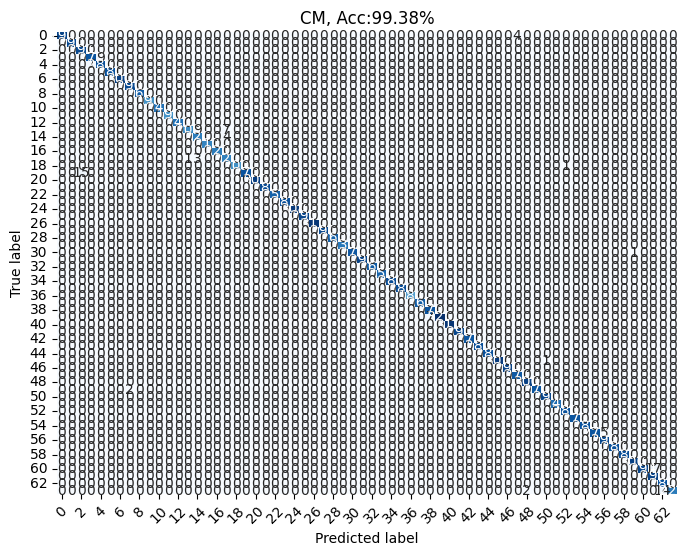

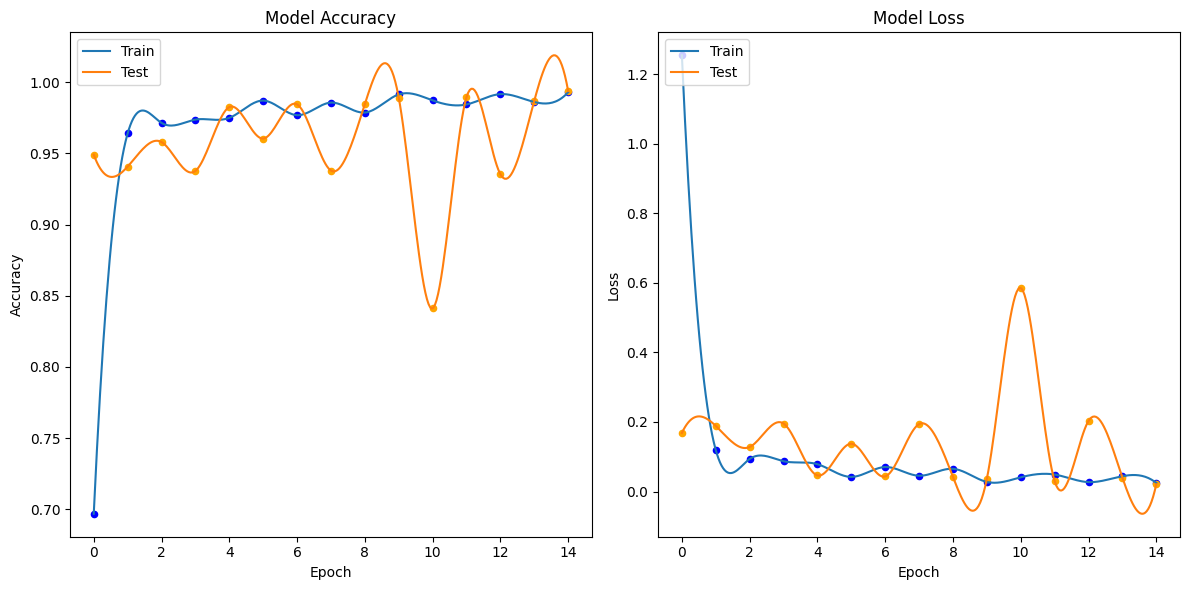

In [39]:
ghostnet_model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback6 = myCallback(patience=20, max_acc=0.99)
history6 = ghostnet_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback6)
ypred6 = ghostnet_model.predict(xtest)
ypred6 = np.argmax(ypred6, axis=1)
plot_confusion_matrix(ytest, ypred6)
plot_training_history(history6)

In [40]:
print(classification_report(ytest, ypred6, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      0.99      0.99       300
     Class 1       1.00      1.00      1.00       290
     Class 2       0.95      1.00      0.97       291
     Class 3       0.98      0.97      0.97       286
     Class 4       0.97      0.98      0.97       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       0.99      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       1.00      0.93      0.96       225
    Class 14       0.95      0.98      0.97       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       0.95    

# Tiny_Yolo

In [41]:
def build_tiny_yolo_classifier(input_shape=(224, 224, 3), num_classes=1000):
    inputs = layers.Input(shape=input_shape)

    # Convolutional layers
    x = layers.Conv2D(16, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(32, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(256, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    x = layers.Conv2D(512, (3, 3), strides=(1, 1), padding='same', activation='leaky_relu')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='same')(x)

    # Sử dụng Global Average Pooling để giảm kích thước và làm lớp cuối cùng cho phân loại
    x = layers.GlobalAveragePooling2D()(x)

    # Fully connected layer cho phân loại
    x = layers.Dense(256, activation='leaky_relu')(x)
    x = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, x)
    return model

# Xây dựng mô hình Tiny YOLO cho phân loại
tiny_yolo_model = build_tiny_yolo_classifier(input_shape=shape_input, num_classes=num_classes)

# Kiểm tra thông tin mô hình
tiny_yolo_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 66, 66, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 66, 66, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 33, 33, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 33, 33, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 17, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,720,544 (6.56 MB)

 Trainable params: 1,720,544 (6.56 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.0167 - loss: 4.1566 - val_accuracy: 0.0172 - val_loss: 4.1281
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0316 - loss: 4.0775 - val_accuracy: 0.0704 - val_loss: 3.8111
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0788 - loss: 3.6738 - val_accuracy: 0.1152 - val_loss: 3.3501
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1375 - loss: 3.2622 - val_accuracy: 0.1722 - val_loss: 3.0327
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1886 - loss: 2.9567 - val_accuracy: 0.2022 - val_loss: 2.8157
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2367 - loss: 2.7164 - val_accuracy: 0.2858 - val_loss: 2.5429
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2899 - loss: 2.4859 - val_accuracy: 0.3331 - val_loss: 2.3520
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3396 - loss: 2.2718 - val_ac

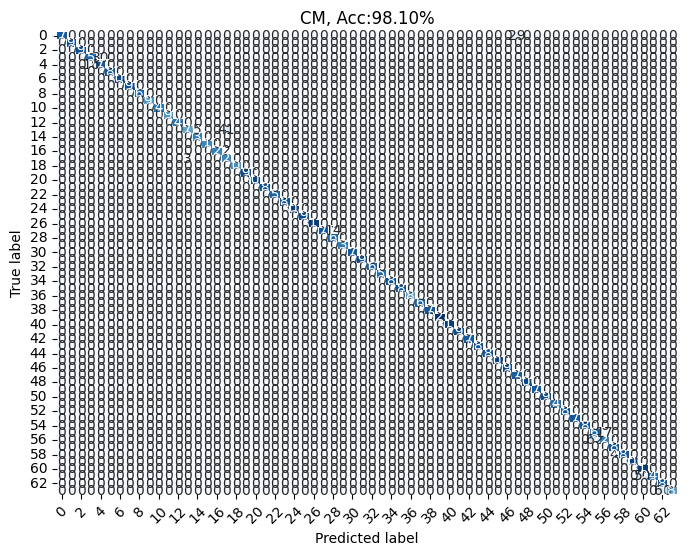

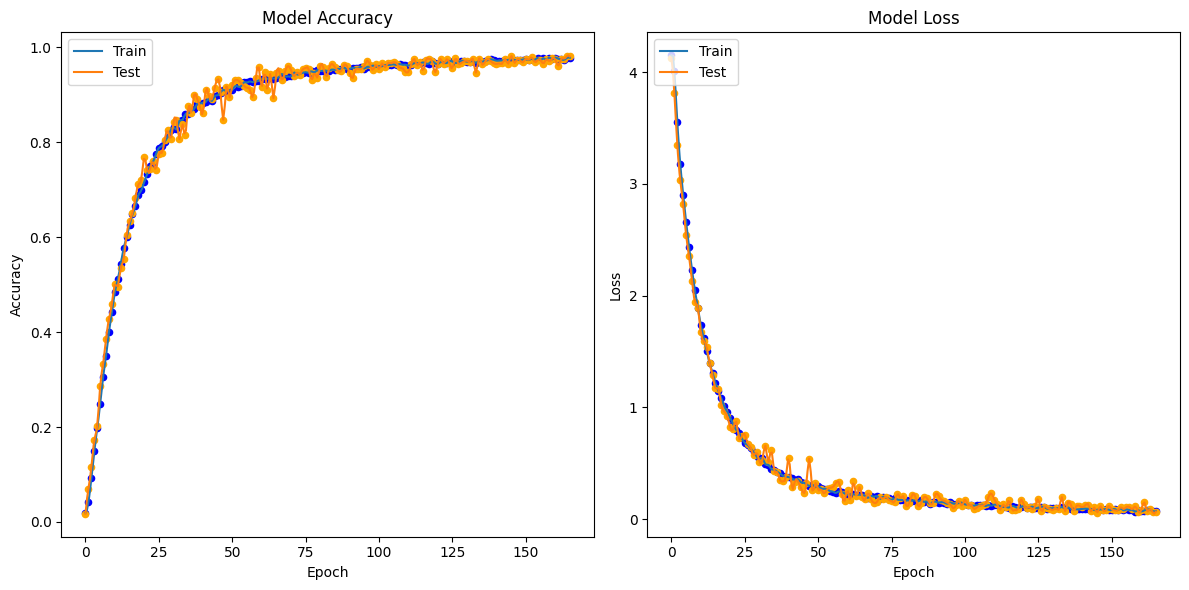

In [42]:
tiny_yolo_model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback7 = myCallback(patience=20, max_acc=0.99)
history7 = tiny_yolo_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback7)
ypred7 = tiny_yolo_model.predict(xtest)
ypred7 = np.argmax(ypred7, axis=1)
plot_confusion_matrix(ytest, ypred7)
plot_training_history(history7)

In [43]:
print(classification_report(ytest, ypred7, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      0.90      0.95       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       0.94      0.90      0.92       286
     Class 4       0.90      0.95      0.92       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       0.98      0.80      0.88       225
    Class 14       0.98      1.00      0.99       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      0.99      1.00       227
    Class 17       0.84    

# FBNet

In [44]:
def mbconv_block(inputs, filters, kernel_size, strides, expansion_factor=6, se_ratio=0.25):
    # Expand
    expanded_filters = inputs.shape[-1] * expansion_factor
    x = layers.Conv2D(expanded_filters, 1, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Depthwise Convolution
    x = layers.DepthwiseConv2D(kernel_size, strides=strides, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Squeeze and Excitation
    if se_ratio:
        se = layers.GlobalAveragePooling2D()(x)
        se = layers.Reshape((1, 1, expanded_filters))(se)
        se = layers.Conv2D(int(expanded_filters * se_ratio), 1, activation='relu')(se)
        se = layers.Conv2D(expanded_filters, 1, activation='sigmoid')(se)
        x = layers.multiply([x, se])
    
    # Project
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    
    # Residual connection if input shape matches
    if strides == 1 and inputs.shape[-1] == filters:
        x = layers.Add()([x, inputs])
    
    return x


def build_fbnet(input_shape=(224, 224, 3), num_classes=1000):
    inputs = layers.Input(shape=input_shape)
    
    # Initial convolution layer
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # MBConv blocks
    x = mbconv_block(x, filters=16, kernel_size=3, strides=1, expansion_factor=1)
    x = mbconv_block(x, filters=24, kernel_size=3, strides=2, expansion_factor=6)
    x = mbconv_block(x, filters=24, kernel_size=3, strides=1, expansion_factor=6)
    x = mbconv_block(x, filters=40, kernel_size=5, strides=2, expansion_factor=6)
    x = mbconv_block(x, filters=40, kernel_size=5, strides=1, expansion_factor=6)
    x = mbconv_block(x, filters=80, kernel_size=3, strides=2, expansion_factor=6)
    x = mbconv_block(x, filters=80, kernel_size=3, strides=1, expansion_factor=6)
    
    # Final layers
    x = layers.Conv2D(1280, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs)
    return model

# Khởi tạo mô hình FBNet
fbnet_model = build_fbnet(input_shape=shape_input, num_classes=num_classes)

# Kiểm tra thông tin mô hình
fbnet_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 66, 66, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 33, 33,    │        432 │ input_layer_8[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │         64 │ conv2d_59[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 33, 33,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 33, 33,    │        256 │ re_lu_14[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │         64 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 33, 33,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_36 │ (None, 33, 33,    │        144 │ re_lu_15[0][0]    │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │         64 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_16 (ReLU)     │ (None, 33, 33,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ re_lu_16[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_27          │ (None, 1, 1, 16)  │          0 │ global_average_p… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 1, 1, 4)   │         68 │ reshape_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 1, 1, 16)  │         80 │ conv2d_61[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 33, 33,    │          0 │ re_lu_16[0][0],   │
│ (Multiply)          │ 16)               │            │ conv2d_62[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 33, 33,    │        256 │ multiply_1[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 33, 33,    │         64 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 565,732 (2.16 MB)

 Trainable params: 557,092 (2.13 MB)

 Non-trainable params: 8,640 (33.75 KB)

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 67s 46ms/step - accuracy: 0.1149 - loss: 3.7845 - val_accuracy: 0.5690 - val_loss: 2.3324
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7123 - loss: 1.4194 - val_accuracy: 0.9400 - val_loss: 0.3092
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9350 - loss: 0.3639 - val_accuracy: 0.9785 - val_loss: 0.1069
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9683 - loss: 0.1590 - val_accuracy: 0.9887 - val_loss: 0.0561
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9808 - loss: 0.0939 - val_accuracy: 0.9906 - val_loss: 0.0404
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9856 - loss: 0.0650 - val_accuracy: 0.9940 - val_loss: 0.0241
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9927 - loss: 0.0398 - val_accuracy: 0.9946 - val_loss: 0.0221
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


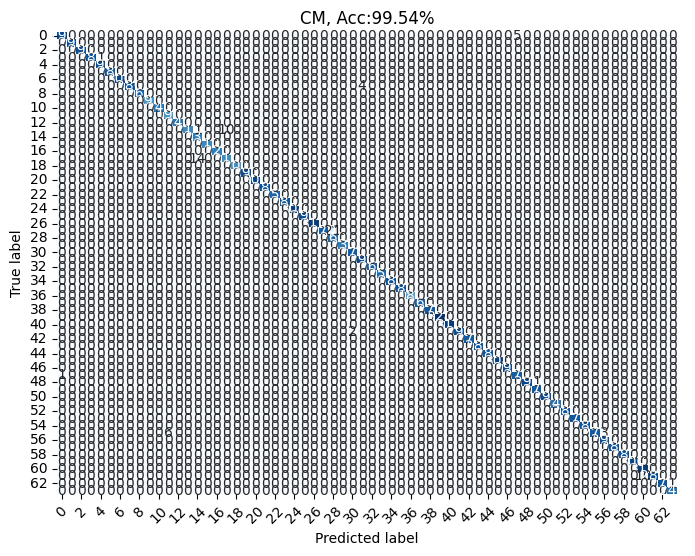

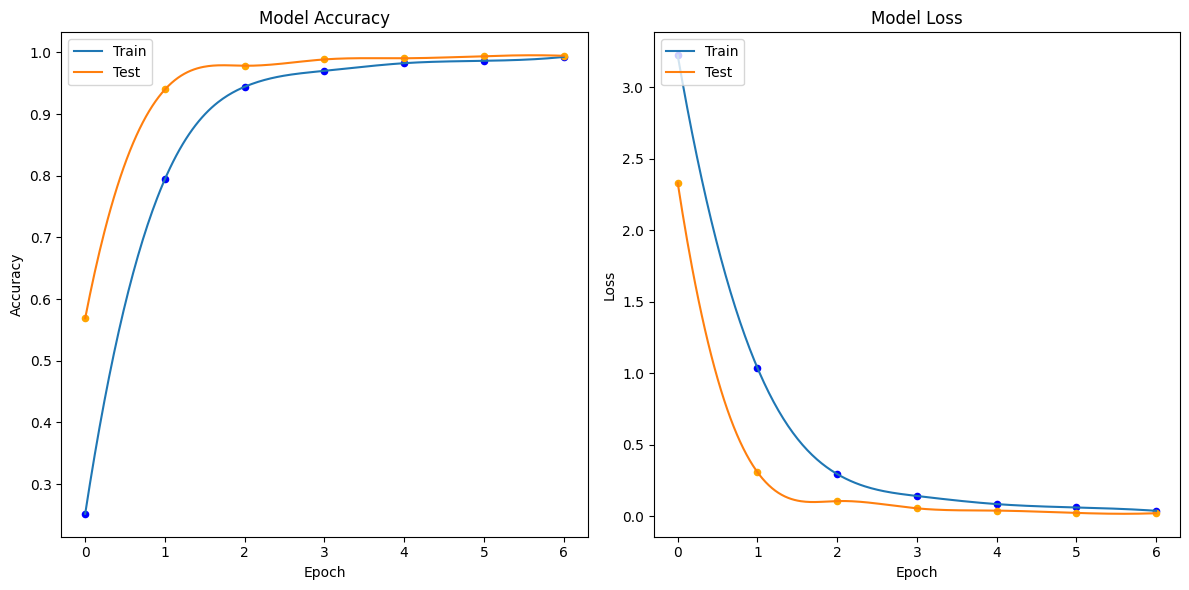

In [45]:
fbnet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback8 = myCallback(patience=20, max_acc=0.99)
history8 = fbnet_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback8)
ypred8 = fbnet_model.predict(xtest)
ypred8 = np.argmax(ypred8, axis=1)
plot_confusion_matrix(ytest, ypred8)
plot_training_history(history8)

In [46]:
print(classification_report(ytest, ypred8, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       1.00      0.98      0.99       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       1.00      1.00      1.00       286
     Class 4       1.00      1.00      1.00       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      0.99      0.99       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       0.97      1.00      0.99       199
    Class 12       1.00      1.00      1.00       242
    Class 13       1.00      0.95      0.97       225
    Class 14       0.94      1.00      0.97       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       0.95    

MCU_Net

In [47]:
class DepthwiseSeparableConv(layers.Layer):
    def __init__(self, out_channels, kernel_size=3, strides=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = layers.DepthwiseConv2D(kernel_size=kernel_size, strides=strides, padding='same', use_bias=False)
        self.pointwise = layers.Conv2D(out_channels, kernel_size=1, padding='same', use_bias=False)
        self.bn = layers.BatchNormalization()
    
    def call(self, inputs):
        x = self.depthwise(inputs)
        x = self.pointwise(x)
        x = self.bn(x)
        return tf.nn.relu(x)
def build_mcu_net(input_shape=(32, 32, 3), num_classes=10):
    inputs = layers.Input(shape=input_shape)
    
    # Tầng đầu vào
    x = DepthwiseSeparableConv(16, strides=2)(inputs)
    x = DepthwiseSeparableConv(32, strides=1)(x)
    x = DepthwiseSeparableConv(64, strides=2)(x)
    x = DepthwiseSeparableConv(128, strides=1)(x)
    x = DepthwiseSeparableConv(256, strides=2)(x)
    x = DepthwiseSeparableConv(512, strides=1)(x)
    
    # Global Average Pooling và tầng đầu ra
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, x)
    return model

# Khởi tạo mô hình
mcu_net_model = build_mcu_net(input_shape=shape_input, num_classes=num_classes)
mcu_net_model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 66, 66, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv        │ (None, 33, 33, 16)     │           139 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv_1      │ (None, 33, 33, 32)     │           784 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv_2      │ (None, 17, 17, 64)     │         2,592 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv_3      │ (None, 17, 17, 128)    │         9,280 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv_4      │ (None, 9, 9, 256)      │        34,944 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_separable_conv_5      │ (None, 9, 9, 512)      │       135,424 │
│ (DepthwiseSeparableConv)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_16     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │        32,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,995 (843.73 KB)

 Trainable params: 213,979 (835.86 KB)

 Non-trainable params: 2,016 (7.88 KB)

Epoch 1/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.0650 - loss: 3.9781 - val_accuracy: 0.2562 - val_loss: 3.2455
Epoch 2/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4086 - loss: 2.8433 - val_accuracy: 0.7420 - val_loss: 1.8377
Epoch 3/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7849 - loss: 1.7090 - val_accuracy: 0.9078 - val_loss: 0.9723
Epoch 4/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9160 - loss: 0.9179 - val_accuracy: 0.9427 - val_loss: 0.5016
Epoch 5/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9491 - loss: 0.5024 - val_accuracy: 0.9566 - val_loss: 0.2927
Epoch 6/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9645 - loss: 0.2965 - val_accuracy: 0.9665 - val_loss: 0.1827
Epoch 7/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9723 - loss: 0.1980 - val_accuracy: 0.9721 - val_loss: 0.1339
Epoch 8/200
729/729 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9761 - loss: 0.1414 - val_ac

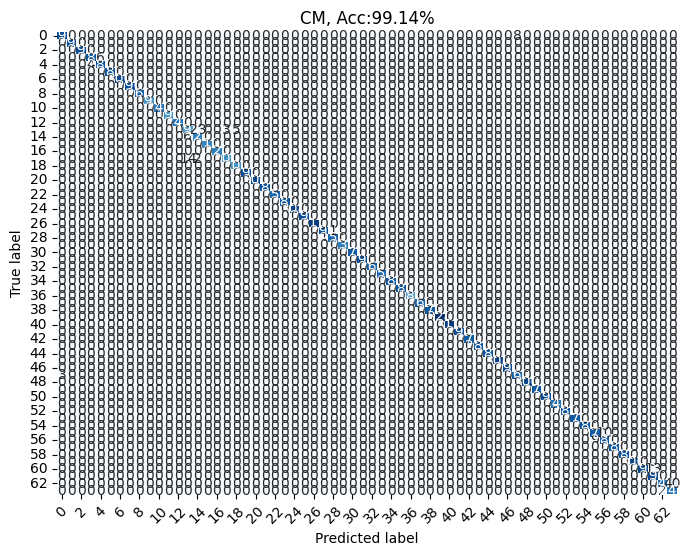

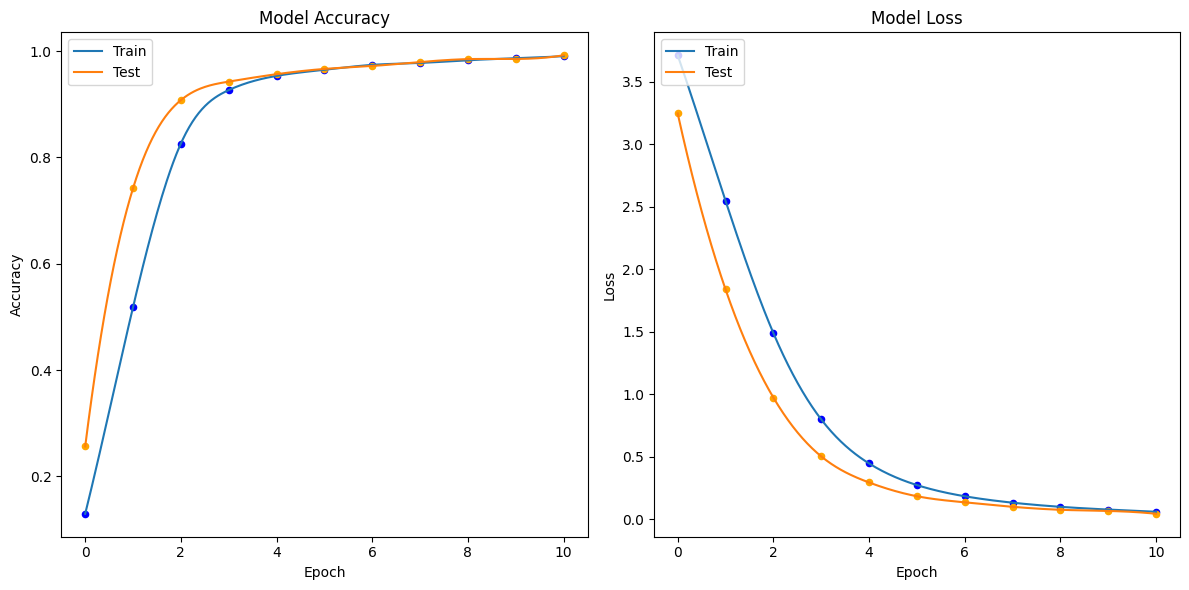

In [48]:
mcu_net_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
callback9 = myCallback(patience=20, max_acc=0.99)
history9 = mcu_net_model.fit(xtrain, ytrain, 
          epochs=200,
          validation_data=[xvalid,yvalid],
          callbacks=callback9)
ypred9 = mcu_net_model.predict(xtest)
ypred9 = np.argmax(ypred9, axis=1)
plot_confusion_matrix(ytest, ypred9)
plot_training_history(history9)

In [49]:
print(classification_report(ytest, ypred9, target_names=[f'Class {i}' for i in range(num_classes)]))

              precision    recall  f1-score   support

     Class 0       0.99      0.97      0.98       300
     Class 1       1.00      1.00      1.00       290
     Class 2       1.00      1.00      1.00       291
     Class 3       0.99      0.98      0.98       286
     Class 4       0.98      0.99      0.98       291
     Class 5       1.00      1.00      1.00       280
     Class 6       1.00      1.00      1.00       300
     Class 7       1.00      1.00      1.00       290
     Class 8       1.00      1.00      1.00       266
     Class 9       1.00      1.00      1.00       197
    Class 10       1.00      1.00      1.00       240
    Class 11       1.00      1.00      1.00       199
    Class 12       1.00      1.00      1.00       242
    Class 13       0.91      0.86      0.88       225
    Class 14       0.90      0.97      0.94       230
    Class 15       1.00      1.00      1.00       217
    Class 16       1.00      1.00      1.00       227
    Class 17       0.99    